In [41]:
# This script is largely based on / adapted from:
# Nora Webb Williams, Andreu Casas, John Wilkerson (2020)
# "Images as Data for Social Science Research" [Source Code]
# Code Ocean. https://doi.org/10.24433/CO.2462313.v1
#
# Code licensed under the MIT License
# Data licensed under CC BY-NC 4.0
# (https://creativecommons.org/licenses/by-nc/4.0/)


#The data used comes from 
# Yang, Yunkang, Matthew hindman, and Trevor Davis. 2022. 
# “Facebook Image Data.” Harvard Dataverse. https://doi.org/10.7910/DVN/RNITKF.
# Paper published: Yunkang Yang, Trevor Davis, Matthew Hindman, 
# Visual misinformation on Facebook, Journal of Communication, Volume 73, Issue 4, August 2023, Pages 316–328, 
# https://doi.org/10.1093/joc/jqac051
# You will need to download the data from Harvard Dataverse via the following link: https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/RNITKF
#License: CC0 1.0 Universal (Public Domain)

# As with any data analysis part, we will start with data preprocessing.
# We will need to do some formatting of the data to get it ready for the CNN model fine-tuning.
# %%
from __future__ import print_function, division
import torch
from torch.autograd import Variable
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torchvision
from torchvision import datasets, models
import matplotlib.pyplot as plt
import numpy as np
plt.ion()   # interactive mode
import os
import pickle
import json
import pandas as pd
from PIL import Image, ImageOps
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns; sns.set()
import torchvision.transforms as transforms
import requests, csv
from pathlib import Path
import imagehash
from torchvision.models import ResNet50_Weights
from ultralytics import YOLO
from torchvision.models import ResNet50_Weights
import urllib.request

os.getcwd() #Set to current working directory

'/Users/clarafochler/Documents/LehreSoSe26Python'

In [42]:

df = pd.read_csv('/Users/clarafochler/Downloads/dataverse_files/public_figures.csv')

DOWNLOAD_PATH = Path("/Users/clarafochler/Downloads/downloads")
DOWNLOAD_PATH.mkdir(exist_ok=True)
failed_urls = []

for _, row in df.iterrows():
    url = row['URL']
    if pd.isna(url):
        continue
    filename = url.split('/')[-1]
    if not (DOWNLOAD_PATH / filename).exists():
        try:
            (DOWNLOAD_PATH / filename).write_bytes(requests.get(url, timeout=10).content)
        except Exception as e:
            print(f"Failed: {url} — {e}")
            failed_urls.append(url)

print(f"{len(failed_urls)} failed downloads.")

# Load downloaded images, keeping labels in sync
all_imgfiles = []
images = []
labels = []

for _, row in df.iterrows():
    url = row['URL']
    if pd.isna(url):
        continue
    filename = url.split('/')[-1]
    filepath = DOWNLOAD_PATH / filename
    if filepath.exists():
        try:
            img = Image.open(filepath).convert('RGB')
            images.append(img)
            all_imgfiles.append(filename)
            labels.append(row['misinfo'])
        except Exception as e:
            print(f"Could not open {filename}: {e}")

print(f"Loaded {len(images)} images, {sum(labels)} misinformation, {len(labels)-sum(labels)} real.")

0 failed downloads.
Loaded 1000 images, nan misinformation, nan real.


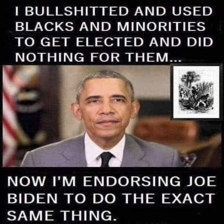

In [43]:
#     a pre-trained Convolutional Neural Net with fixed input size. For example,
#     the required input size for a commonly used pretrained CNN (ResNet), is
#     224x224x3.
images_resnetsize = []
for img in images:
    smaller_img = img.resize((224,224))
    images_resnetsize.append(smaller_img)

# - print the same image after resizing it for ResNet
images_resnetsize[1]

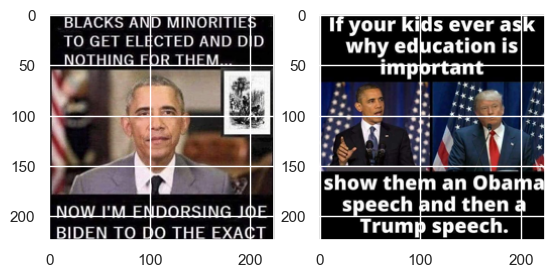

In [44]:

# - this is not ideal. Since the original image wasn't square, the resized 
#   224x224 version is a bit deformed. To avoid deforming the image while still 
#   resizing it to 224x224, crop out the top and the bottom first.

# ... calculate the difference between the height and the width, to see how much of
#     the top/bottom OR left/right you'll need to crop. Then go ahead and crop those
#     parts out before resizing to 224x224
crop_res_images = []
for img in images:
    height = img.height
    width = img.width
    hw_dif = abs(height - width)
    hw_halfdif = hw_dif / 2
    crop_leftright = width > height
    if crop_leftright:
        y0 = 0
        y1 = height
        x0 = 0 + hw_halfdif
        x1 = width - hw_halfdif        
    else:
        y0 = 0 + hw_halfdif
        y1 = height - hw_halfdif
        x0 = 0
        x1 = width
    cropped_img = img.crop((x0, y0, x1, y1))
    cropped_resized = cropped_img.resize((224,224))
    crop_res_images.append(cropped_resized)

# - see how they are all square now
f, axarr = plt.subplots(1, 2)
axarr[0].imshow(crop_res_images[1])
axarr[1].imshow(crop_res_images[2])
plt.show()

- The nice thing about cropping and resizing images to the same size is that
  then we can more easily compare them

- For example, one can transform the 3-d matrices to flat vectors and
  then use vector similarity measures such as Cosine Similarity to find duplicate
  images or to find images that are similar to each other

... let's reduce the images even more so we don't generate extremely large vectors

In [45]:
verysmall_images = []
for img in images:
    img_gray = ImageOps.grayscale(img)  # optional, but necessary for cosine similarity to detect duplicates even if there are small color differences
    img_eq   = ImageOps.equalize(img_gray)  # optional, but can help with cosine similarity to detect duplicates even if there are small brightness differences
    height = img_gray.height
    width = img_gray.width
    hw_dif = abs(height - width)
    hw_halfdif = hw_dif / 2
    crop_leftright = width > height
    if crop_leftright:
        y0 = 0
        y1 = height
        x0 = 0 + hw_halfdif
        x1 = width - hw_halfdif        
    else:
        y0 = 0 + hw_halfdif
        y1 = height - hw_halfdif
        x0 = 0
        x1 = width
    cropped_img = img.crop((x0, y0, x1, y1))
    cropped_resized = cropped_img.resize((15,15)) ###### 15 X 15 #######
    verysmall_images.append(cropped_resized)

# - take a look at the size of the images we'll flatten. They are pretty small (15x15), but
#   the resulting will be already of a considerable size: 15x15x3 = 650
verysmall_images[0]

In [46]:
# - now let's transform these very small 3d image matrices to vector by flattening them out
img_vectors = []
for vsmall_img in verysmall_images:
    img_vect = list(np.array(vsmall_img).flatten())
    img_vectors.append(img_vect)

as with every data we will need to make sure there are no duplicates in the data.
this will be specifically important for the fine-tuning of the CNN, so there is no data leakage between the training
and the test set.

options for similarity measures include

***pHash*** (specific algorithm of ***perceptual hashing***) which is a hashing method calculated based on the image content.
specifically, it is calculated based on the discrete cosine transform (DCT) of the image, which captures the low-frequency components of the image.
Images with similar content will have similar phash values, and the distance between the phash values can be used as
a measure of visual/structural similarity between the images — however, it is NOT a semantic similarity measure.
it is robust against minor distortions (blur, compression, small rotations), but cannot capture meaning:
two different images of the same object will not necessarily have similar phash values.
a recommended threshold of T=22 can be applied to determine if two images are from the same source.


***feature based hashing*** is also a common method, which uses local features of images to create a hash value. 
This method is more robust to changes in image size, rotation, and other transformations, making it a good choice for
duplicate detection in images that may have been modified or edited.

We will start with the ***cosine similarity***. It measures the cosine of the angle between two vectors, which ranges from 
-1 (completely dissimilar) to 1 (completely similar).
The cosine similarity is calculated as the dot product of the two vectors divided by the product of their magnitudes.
It is not affected by the magnitude of the vectors, which can be useful when comparing images that may have different
brightness or contrast levels.

which measure you choose will depend on the specific characteristics of your images and the requirements of your application.
You may want to experiment with different measures to see which one works best for your specific use case.

- let's get started exploring image similarity. Let's first stack the list of vectors into a 
numpy matrix to which we'll then easily fit a cosine_similarity function calculating
the similarity between each possible row pair. 

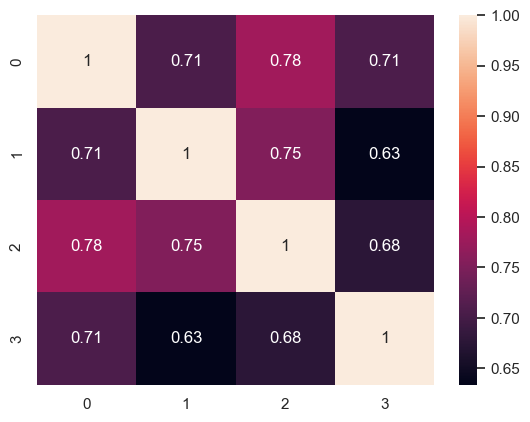

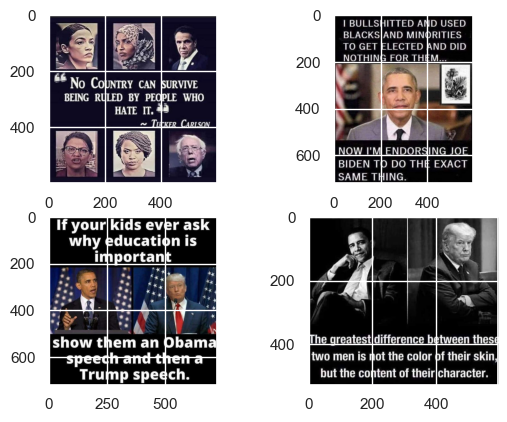

In [47]:
img_array = np.array(img_vectors[:4])
img_array.shape

img_array

# - calculate cosine similarity
sim_mat = cosine_similarity(img_array)

# - look at the resulting similarity matrix
sim_mat

# - let's plot these image similarities using a heat map.
ax = sns.heatmap(sim_mat, annot=True)
plt.show()
# images 0 and 2 are most similar (0.78), while images 1 and 3 are most dissimilar (0.63)
# ... let's see:
f, axarr = plt.subplots(2, 2)
axarr[0,0].imshow(images[0])
axarr[0,1].imshow(images[1])
axarr[1,0].imshow(images[2])
axarr[1,1].imshow(images[3])
plt.show()

Scores are high (~0.65-0.78) because pixel similarity captures brightness patterns, not content.
This works for near-exact duplicates (score > 0.95) but misses edited/recolored copies — pHash is more robust.

Notice for pHash we do not need to convert the images to vectors.
We can directly calculate the pHash values on the image objects.
Calculate pHash values for both images
Unlike cosine similarity, pHash does not require grayscale/resize preprocessing
because it internally normalizes the image before hashing.

Hamming distance: 34
Similarity: 0.47


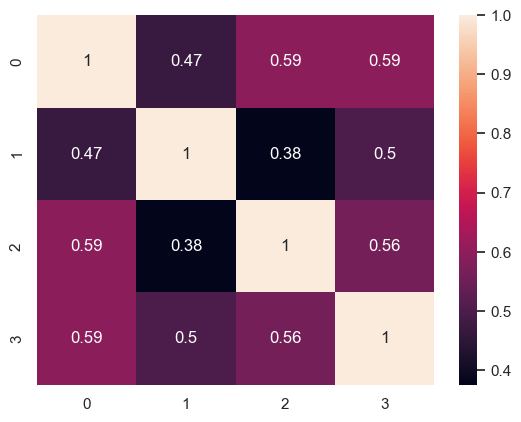

In [49]:
hash1 = imagehash.phash(images[0])
hash2 = imagehash.phash(images[1])
hash3 = imagehash.phash(images[2])
hash4 = imagehash.phash(images[3])

# Calculate the Hamming distance between the hashes
hamming_distance = hash1 - hash2

# Normalize to 0-1 similarity (64 = total hash bits)
similarity = 1 - hamming_distance / 64

print(f"Hamming distance: {hamming_distance}")
print(f"Similarity: {similarity:.2f}")

hashes = [imagehash.phash(img) for img in images[:4]]

sim_mat_phash = np.zeros((4, 4))
for i in range(4):
    for j in range(4):
        hamming_distance = hashes[i] - hashes[j]
        sim_mat_phash[i][j] = 1 - hamming_distance / 64 # pHash produces a 64-bit hash per image; Hamming distance counts differing bits (0-64), dividing by 64 normalizes to 0-1 similarity

ax = sns.heatmap(sim_mat_phash, annot=True)
plt.show()

pHash scores are much lower (0.38-0.59) than cosine similarity (0.65-0.78) for the same images —
pHash captures structural/frequency patterns via DCT, making it more sensitive to actual visual differences.

- load a pretrained ResNet50 trained for ImageClassification
NOTE: This step can take a while, because it will need to first download the model
      We use torchvision to download pre-trained weights.

In [51]:
from torchvision.models import ResNet50_Weights
import urllib.request

# - load a pretrained ResNet50 trained for ImageClassification
# NOTE: This step can take a while, because it will need to first download the model
#       We use torchvision to download pre-trained weights.
model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
model.eval()

# - take a look at the model architecture
model


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [52]:
# - load our file with the 1,000 class labels
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json",
    "imagenet_labels.json"
)
inet_labs = json.load(open("imagenet_labels.json"))

# - take a look at the type of object classes into which ResNet50 classifies images
inet_labs

['tench',
 'goldfish',
 'great white shark',
 'tiger shark',
 'hammerhead shark',
 'electric ray',
 'stingray',
 'cock',
 'hen',
 'ostrich',
 'brambling',
 'goldfinch',
 'house finch',
 'junco',
 'indigo bunting',
 'American robin',
 'bulbul',
 'jay',
 'magpie',
 'chickadee',
 'American dipper',
 'kite',
 'bald eagle',
 'vulture',
 'great grey owl',
 'fire salamander',
 'smooth newt',
 'newt',
 'spotted salamander',
 'axolotl',
 'American bullfrog',
 'tree frog',
 'tailed frog',
 'loggerhead sea turtle',
 'leatherback sea turtle',
 'mud turtle',
 'terrapin',
 'box turtle',
 'banded gecko',
 'green iguana',
 'Carolina anole',
 'desert grassland whiptail lizard',
 'agama',
 'frilled-necked lizard',
 'alligator lizard',
 'Gila monster',
 'European green lizard',
 'chameleon',
 'Komodo dragon',
 'Nile crocodile',
 'American alligator',
 'triceratops',
 'worm snake',
 'ring-necked snake',
 'eastern hog-nosed snake',
 'smooth green snake',
 'kingsnake',
 'garter snake',
 'water snake',
 'vin

In [53]:
# - a function to preprocess an image file so it fits the ResNet50 input requirements.
#   This function already does the cropping and resizing for you
def data_transform(train=True, mean=[0.485, 0.456, 0.406],
                  sd=[0.229, 0.224, 0.225],
                  scale=256, random_crop=224):
    """
    Description: This function creates an object to transform train and
        test (or only testing) images.
    Parameters:
        `train`: type <bool> indicating if the object will need to be used
                    to transform training and testing images (=True) or
                    only testing.
        `mean`: type <list> of 3 floats indicating the mean value of the 3 RGB
                    image inputs.
        `sd`: type <list> of 3 floats indicating the standard deviation of
                    the 3 RGB mean inputs.
        `scale`: type <int> indicating the new size to give to the train and
                    test data (e.g. 256x256 pixel images).
        `random_crop`: type <int> indicating the size of the part of the image
                    really used for training-testing (e.g. 224x224)
    Output:
        An object to be used for preprocessing the train and test images
    Example:
        preprocess = data_transform()
    """
    if train:
        data_transforms = transforms.Compose([
            transforms.Resize(scale),                  # updated: Scale() → Resize()
            transforms.RandomResizedCrop(random_crop), # updated: RandomSizedCrop() → RandomResizedCrop()
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(mean, sd)
        ])
    else:
        data_transforms = transforms.Compose([
            transforms.Resize(scale),                  # updated: Scale() → Resize()
            transforms.CenterCrop(random_crop),
            transforms.ToTensor(),
            transforms.Normalize(mean, sd)
        ])
    return data_transforms

# - pass the images through ResNet50 and get some model predictions
resnet50_preprocess = data_transform(train=False) # preprocessing function defined above for ResNet50

# Set ResNet to eval mode: BatchNorm will use learned statistics instead of
# mini-batch stats (unreliable at batch_size=1) → stable, correct predictions
model.eval()

softmax = torch.nn.Softmax(dim=1)  # a softmax model to transform model predictions to predicted probabilities
pred_labels = pd.DataFrame()

for img_file in all_imgfiles:
    # ... load the image
    img = Image.open(DOWNLOAD_PATH / img_file).convert('RGB')

    # ... preprocess/normalize the image
    img_transformed = Variable(resnet50_preprocess(img).unsqueeze(0))

    # ... model predictions (wrap in no_grad for inference efficiency)
    with torch.no_grad():
        model_out = model(img_transformed)

    # ... transform model predictions to predicted probabilities
    pred_probs = softmax(model_out)

    # ... pull the maximum predicted probability and class
    max_pr, max_class = torch.max(pred_probs, dim=1)

    # ... pull the human-readable label for this max class
    max_label = inet_labs[max_class.item()]

    # ... save the info
    new_row = pd.DataFrame({
        'img_file': img_file,
        'max_pr': round(max_pr.item(), 4),
        'max_label': max_label
    }, index=[0])
    pred_labels = pd.concat((pred_labels, new_row))

pred_labels

,img_file,max_pr,max_label
0,_image_5f5307d47af460.54174201.jpg,0.6428,comic book
0,_image_5f5f92b3914ec8.54292244.jpg,0.2840,website
0,_image_5ebf38b5b88320.37290901.jpg,0.7855,Windsor tie
0,_image_5f6a6067575bc8.87916900.jpg,0.8519,suit
0,_image_5f642c5778ca02.59185169.jpg,0.4044,website
...,...,...,...
0,_image_5eedbd67eb8912.40201669.jpg,0.1961,website
0,_image_5f6446dbc23852.20464025.jpg,0.1727,Windsor tie
0,_image_5f4314686f2bd3.30846909.jpg,0.9010,website
0,_image_5f45eb98eedda9.59109500.jpg,0.9724,scoreboard


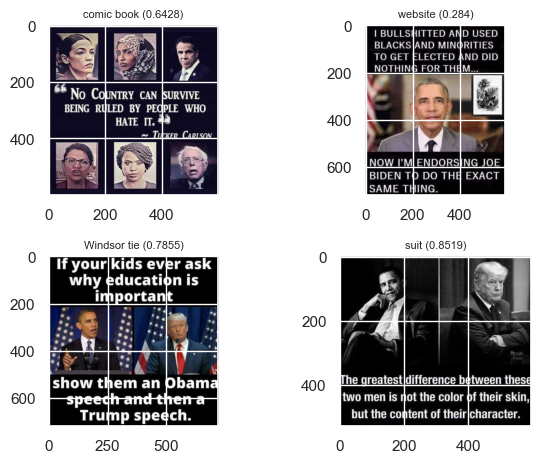

In [54]:
# - How do those labels compare with the images themselves?
f, axarr = plt.subplots(2, 2)
for idx, (ax, i) in enumerate(zip(axarr.flatten(), range(4))):
    ax.imshow(images[i])
    label = pred_labels.iloc[i]['max_label']
    prob = pred_labels.iloc[i]['max_pr']
    ax.set_title(f"{label} ({prob})", fontsize=8)
plt.tight_layout()
plt.show()
axarr[0, 0].imshow(images[0])
axarr[0, 1].imshow(images[1])
axarr[1, 0].imshow(images[2])
axarr[1, 1].imshow(images[3])
plt.show()

The ResNet model does not create meaningful labels - e.g. labeling images as political Memes - why could that be?

Object Detection using YOLOv8

If we wanted to fine-tune YOLOv8 on our own data, we would need to:
1. Annotate our images (draw bounding boxes + assign class labels)
2. Export those annotations in YOLO format (.txt file per image)
3. Set up a data.yaml config file pointing to our dataset


Since we are only using the pretrained YOLOv8 as an autotagger here,
we can directly pass any image and get bounding boxes + labels as output.


0: 640x640 6 persons, 1 tie, 137.3ms
1: 640x640 1 person, 1 tie, 137.3ms
2: 640x640 2 persons, 2 ties, 137.3ms
3: 640x640 2 persons, 1 tie, 137.3ms
Speed: 5.0ms preprocess, 137.3ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 640)


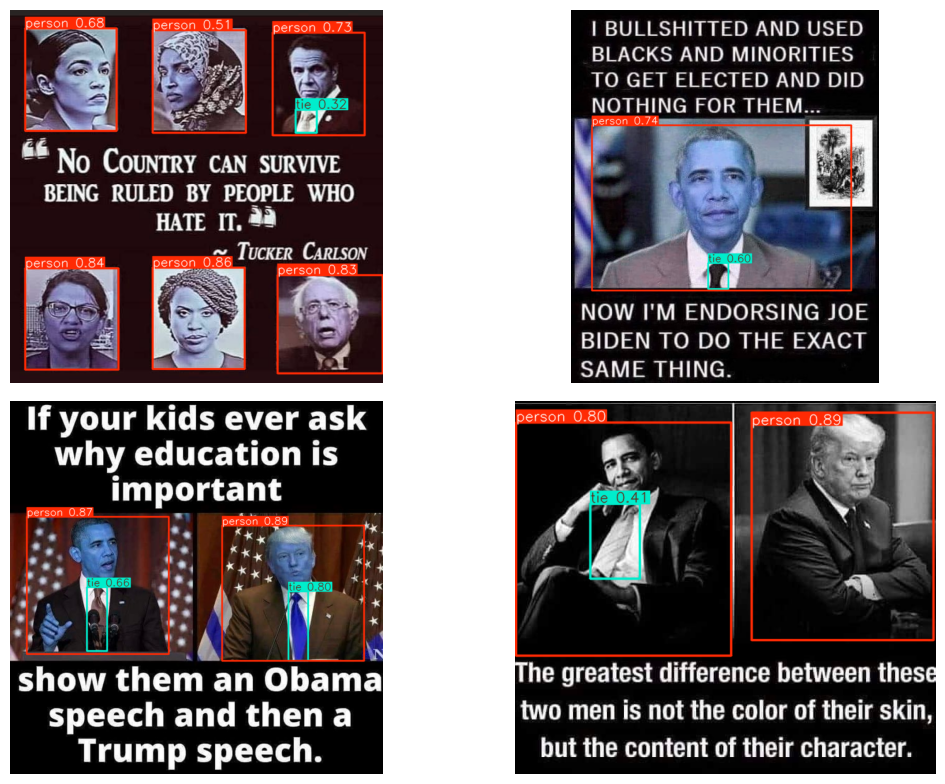

In [ ]:
model_yolo = YOLO("yolov8n.pt")

results = model_yolo([str(DOWNLOAD_PATH / f) for f in all_imgfiles[:4]])

f, axarr = plt.subplots(2, 2, figsize=(12, 8))
for i, (r, ax) in enumerate(zip(results, axarr.flatten())):
    ax.imshow(r.plot())  # r.plot() returns image array with bounding boxes drawn
    ax.axis('off')
plt.tight_layout()
plt.show()

YOLOv8 detects generic objects (person, tie) but cannot identify who these people are.
Note image 2 (top right): no person detected — what could be the reason?
Also why does it detect the ties, but not the glasses?